In [3]:
import pandas as pd
import numpy as np
from io import StringIO
import os
## STEP 1: IMPORT LIBRARIES + CLEAN DATA  + DEFINE FUNCTIONS + CHECK FILES  + EXTRACT BASELINE VALUES

# ==========================================================
# FUNCTION: LOAD DATA FILE
# ==========================================================
def load_data(filename):
    """
    Load a data file from the ../data folder.

    Parameters:
        filename (str): name of the file (e.g. "Data_GG.csv")

    Returns:
        lines (list): all lines from the file
    """
    path = os.path.join("..", "data", filename)

    with open(path, "r", encoding="utf-8") as f:
        lines = f.readlines()

    return lines


# ==========================================================
# FUNCTION: PROCESS ONE FILE
# ==========================================================
def process_file(filename):

    # ---------- STEP 1: LOAD FILE ----------
    lines = load_data(filename)

    # ---------- STEP 2: FIND K-PUSH AND K-MOVE BLOCKS ----------
    idx_push = None
    idx_move = None

    for i, line in enumerate(lines):
        if "K-Push" in line:
            idx_push = i
        if "K-Move" in line and idx_move is None:
            idx_move = i

    # ---------- STEP 3: SPLIT FILE ----------
    if idx_push < idx_move:
        push_lines = lines[idx_push:idx_move]
        move_lines = lines[idx_move:]
    else:
        push_lines = lines[idx_push:]
        move_lines = lines[idx_move:idx_push]

    # ---------- STEP 4: CLEAN K-PUSH ----------
    header_idx_push = next(i for i, line in enumerate(push_lines) if "temps (seconde)" in line)

    push_str = "".join(push_lines[header_idx_push:])

    df_push = pd.read_csv(
        StringIO(push_str),
        sep=r"\t|,",
        engine="python",
        on_bad_lines="skip"
    )

    df_push = df_push.dropna(axis=1, how='all')

    df_push = df_push.rename(columns={
        "temps (seconde)": "time",
        "CHANNEL_1": "force"
    })

    df_push = df_push[["time", "force"]]
    df_push = df_push.apply(pd.to_numeric, errors='coerce').dropna()

    # ---------- STEP 5: ROBUST BASELINE EXTRACTION ----------
    baseline = {"wrist": [], "shoulder": []}

    for line in move_lines:
        if "Quaternion de base" in line:

            # Try splitting with tab first
            parts = line.strip().split("\t")

            # If tab split fails → try comma
            if len(parts) < 5:
                parts = line.strip().split(",")

            sensor_name = parts[0]

            # Extract numeric values safely
            values = []
            for x in parts[1:]:
                try:
                    values.append(float(x))
                except:
                    continue

            # Keep only first 4 values (qx, qy, qz, qw)
            values = values[:4]

            # Assign values to correct sensor
            if "S121577" in sensor_name:
                baseline["wrist"] = values
            elif "S121578" in sensor_name:
                baseline["shoulder"] = values

    # ---------- FIND HEADER ----------
    header_idx_move = next(i for i, line in enumerate(move_lines) if "temps (seconde)" in line)

    move_data_lines = move_lines[header_idx_move + 1:]

    # ---------- PARSE DATA ----------
    split_rows = []
    for line in move_data_lines:
        row = line.strip().split("\t")

        if len(row) < 2:
            row = line.strip().split(",")

        split_rows.append(row)

    df_move = pd.DataFrame(split_rows)

    df_move = df_move.dropna(axis=1, how='all')
    df_move = df_move.apply(pd.to_numeric, errors='coerce')
    df_move = df_move.interpolate(method='linear')
    df_move = df_move.dropna()

    # ---------- STEP 6: EXTRACT SENSORS ----------
    df_wrist = df_move.iloc[:, [0,1,2,3,4]].copy()
    df_wrist.columns = ["time","qx","qy","qz","qw"]

    df_shoulder = df_move.iloc[:, [0,6,7,8,9]].copy()
    df_shoulder.columns = ["time","qx","qy","qz","qw"]

    # ---------- FINAL CHECK ----------
    print(f"\n===== FILE: {filename} =====")

    print("K-Push:\n", df_push.head())

    print("\nWrist (S121577):\n", df_wrist.head())

    print("\nShoulder (S121578):\n", df_shoulder.head())

    print("\nBaseline wrist:", baseline["wrist"])
    print("Baseline shoulder:", baseline["shoulder"])

    print("\nShapes:", df_push.shape, df_wrist.shape, df_shoulder.shape)

    return df_push, df_wrist, df_shoulder, baseline


# ==========================================================
# MAIN SCRIPT
# ==========================================================

# ---------- SELECT FILE(S) ----------
files = ["Data_Lo_D_1.csv"]

# files = ["Data_droite.csv", "Data_GG.csv"]  # for multiple files

# ---------- PROCESS FILE(S) ----------
results = {}

for file in files:
    df_push, df_wrist, df_shoulder, baseline = process_file(file)

    results[file] = {
        "push": df_push,
        "wrist": df_wrist,
        "shoulder": df_shoulder,
        "baseline": baseline
    }



===== FILE: Data_Lo_D_1.csv =====
K-Push:
     time   force
0  0.000  0.4864
1  0.001  0.4776
2  0.002  0.4503
3  0.003  0.4519
4  0.004  0.4711

Wrist (S121577):
     time        qx        qy        qz        qw
0  0.000  0.476135  0.443481  0.257568  0.714233
1  0.004  0.476059  0.443648  0.257607  0.714226
2  0.008  0.475903  0.443951  0.257666  0.714130
3  0.012  0.475748  0.444284  0.257665  0.714034
4  0.016  0.475593  0.444586  0.257633  0.713969

Shoulder (S121578):
     time        qx        qy        qz        qw
0  0.000 -0.492126  0.111816 -0.044678  0.862122
1  0.004 -0.492139  0.111880 -0.044679  0.862112
2  0.008 -0.492142  0.111973 -0.044710  0.862088
3  0.012 -0.492168  0.112002 -0.044740  0.862079
4  0.016 -0.492228  0.112002 -0.044770  0.862047

Baseline wrist: [0.446, 0.468, 0.205, 0.735]
Baseline shoulder: [-0.482, 0.116, -0.05, 0.867]

Shapes: (50000, 2) (12505, 5) (12505, 5)


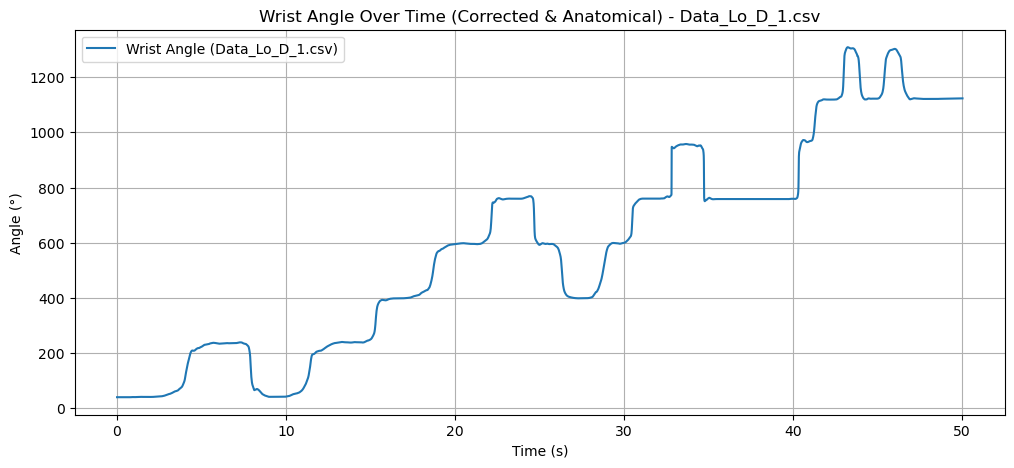

===== FILE: Data_Lo_D_1.csv =====
Min angle: 39.94861325483116
Max angle: 1308.639452213942


In [12]:
## STEP 2 - CONVERT QUATERNION TO ANATOMICAL ANGLE + PLOT

import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# FUNCTION: CONVERT QUATERNION TO ANATOMICAL ANGLE
# ==========================================================
def quaternion_to_angle_x_corrected(df_quat, baseline_deg):
    """
    Convert quaternion to anatomically meaningful wrist/elbow angle.
    Preserves the sinusoidal shape of flexion/extension cycles.
    """

    qx = df_quat["qx"].values
    qy = df_quat["qy"].values
    qz = df_quat["qz"].values
    qw = df_quat["qw"].values

    # ---------- RAW ANGLE (rad) ----------
    angle_raw = np.arctan2(
        2*(qw*qx + qy*qz),
        1 - 2*(qx**2 + qy**2)
    )

    # ---------- UNWRAP ----------
    angle_unwrapped = np.unwrap(angle_raw)

    # ---------- DEGREES ----------
    angle_deg = np.degrees(angle_unwrapped)

    # ---------- ZERO-REFERENCE ----------
    angle_zeroed = angle_deg - angle_deg[0]

    # Invert direction if needed
    if np.mean(angle_zeroed) < 0:
        angle_zeroed = -angle_zeroed

    # ---------- APPLY BASELINE ----------
    angle_anatomical = angle_zeroed + baseline_deg

    df_angles = df_quat[["time"]].copy()
    df_angles["angle"] = angle_anatomical

    return df_angles


# ==========================================================
# MULTI-FILE PROCESSING
# ==========================================================
files = ["Data_Lo_D_1.csv"]  # Exemple
baseline_angles = {"Data_Lo_D_1.csv": 40}  # Modifier selon vidéo

angles_results = {}

for file in files:
    # Récupération du DF wrist depuis process_file
    df_wrist = results[file]["wrist"]

    # Interpolation linéaire pour lisser (optionnel)
    df_wrist = df_wrist.interpolate(method='linear').dropna()

    manual_baseline = baseline_angles[file]

    # Convertir quaternion → angle anatomique
    df_wrist_angles = quaternion_to_angle_x_corrected(df_wrist, manual_baseline)

    # Stocker résultats
    angles_results[file] = df_wrist_angles

    # ---------- PLOT ----------
    plt.figure(figsize=(12,5))
    plt.plot(df_wrist_angles["time"], df_wrist_angles["angle"], label=f"Wrist Angle ({file})")
    plt.xlabel("Time (s)")
    plt.ylabel("Angle (°)")
    plt.title(f"Wrist Angle Over Time (Corrected & Anatomical) - {file}")
    plt.legend()
    plt.grid(True)
    plt.show()

    # ---------- CHECK RANGE ----------
    print(f"===== FILE: {file} =====")
    print("Min angle:", df_wrist_angles["angle"].min())
    print("Max angle:", df_wrist_angles["angle"].max())

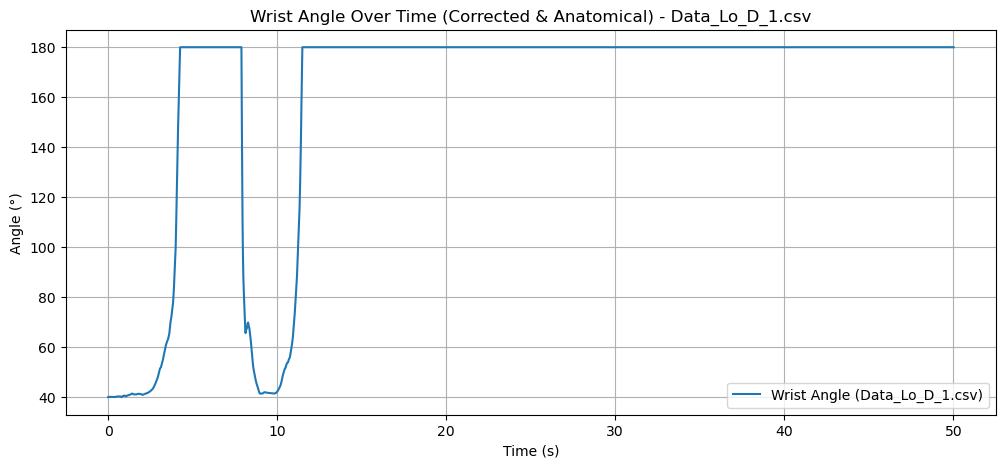

===== FILE: Data_Lo_D_1.csv =====
Min angle: 39.94861325483116
Max angle: 180.0


In [13]:
## STEP 2 - CONVERT QUATERNION TO ANATOMICAL ANGLE + PLOT
import numpy as np
import matplotlib.pyplot as plt

def quaternion_to_angle_x_corrected(df_quat, baseline_deg=40):
    """
    Robust conversion from quaternion → anatomical angle.
    Preserves sinusoidal shape of flexion/extension.
    """

    qx = df_quat["qx"].values
    qy = df_quat["qy"].values
    qz = df_quat["qz"].values
    qw = df_quat["qw"].values

    # ---------- RAW ANGLE ----------
    angle_raw = np.arctan2(
        2*(qw*qx + qy*qz),
        1 - 2*(qx**2 + qy**2)
    )

    # ---------- UNWRAP ----------
    angle_unwrapped = np.unwrap(angle_raw)

    # ---------- TO DEGREES ----------
    angle_deg = np.degrees(angle_unwrapped)

    # ---------- ZERO-REFERENCE ----------
    angle_zeroed = angle_deg - angle_deg[0]

    # Invert direction if needed
    if np.mean(angle_zeroed) < 0:
        angle_zeroed = -angle_zeroed

    # ---------- APPLY BASELINE ----------
    angle_anatomical = angle_zeroed + baseline_deg

    # Clip to physiological range (30–180°)
    angle_anatomical = np.clip(angle_anatomical, 30, 180)

    df_angles = df_quat[["time"]].copy()
    df_angles["angle"] = angle_anatomical

    return df_angles


# ==========================================================
# MULTI-FILE PROCESSING
# ==========================================================
files = ["Data_Lo_D_1.csv"]
baseline_angles = {"Data_Lo_D_1.csv": 40}
angles_results = {}

for file in files:
    df_wrist = results[file]["wrist"]

    # Interpolation pour lisser (optionnel)
    df_wrist = df_wrist.interpolate(method="linear").dropna()

    manual_baseline = baseline_angles[file]

    # Convert quaternion → anatomical angle
    df_wrist_angles = quaternion_to_angle_x_corrected(df_wrist, manual_baseline)

    angles_results[file] = df_wrist_angles

    # ---------- PLOT ----------
    plt.figure(figsize=(12,5))
    plt.plot(df_wrist_angles["time"], df_wrist_angles["angle"], label=f"Wrist Angle ({file})")
    plt.xlabel("Time (s)")
    plt.ylabel("Angle (°)")
    plt.title(f"Wrist Angle Over Time (Corrected & Anatomical) - {file}")
    plt.legend()
    plt.grid(True)
    plt.show()

    # ---------- DEBUG ----------
    print(f"===== FILE: {file} =====")
    print("Min angle:", df_wrist_angles["angle"].min())
    print("Max angle:", df_wrist_angles["angle"].max())

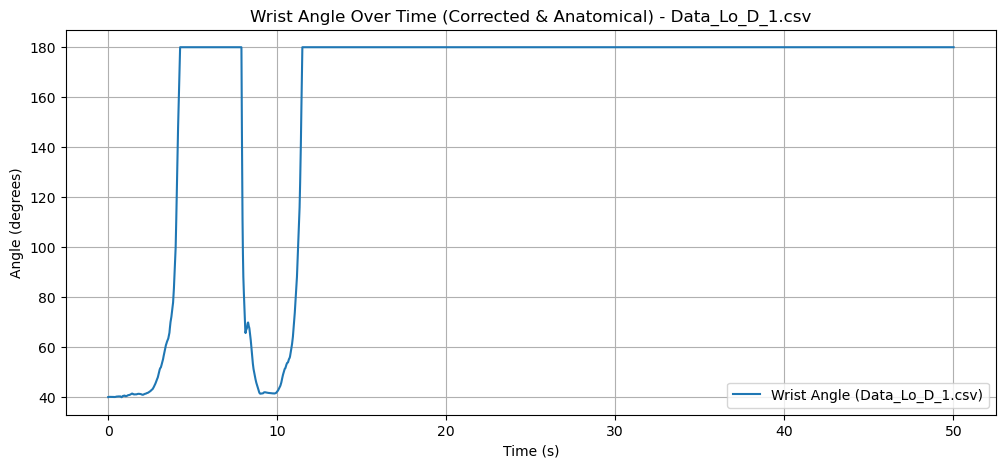

===== FILE: Data_Lo_D_1.csv =====
Min angle: 39.94861325483116
Max angle: 180.0


In [14]:
## STEP 2 - CONVERT QUATERNION TO ANATOMICAL ANGLE + PLOT

import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# FUNCTION: CONVERT QUATERNION TO ANATOMICAL ANGLE
# ==========================================================
def quaternion_to_angle_x_corrected(df_quat, baseline_deg):
    """
    Convert quaternion to anatomically meaningful wrist/elbow angle.

    Steps:
    1. Compute raw angle from quaternion
    2. Unwrap angle to avoid discontinuities (-pi/+pi jumps)
    3. Convert to degrees
    4. Zero-reference to first value
    5. Apply baseline
    6. Clip to physiological range (30° - 180°)
    """

    # Extract quaternion components
    qx = df_quat["qx"].values
    qy = df_quat["qy"].values
    qz = df_quat["qz"].values
    qw = df_quat["qw"].values

    # ---------- STEP 1: RAW ANGLE (rad) ----------
    angle_raw = np.arctan2(
        2*(qw*qx + qy*qz),
        1 - 2*(qx**2 + qy**2)
    )

    # ---------- STEP 2: UNWRAP ----------
    angle_unwrapped = np.unwrap(angle_raw)

    # ---------- STEP 3: CONVERT TO DEGREES ----------
    angle_deg = np.degrees(angle_unwrapped)

    # ---------- STEP 4: ZERO-REFERENCE ----------
    angle_zeroed = angle_deg - angle_deg[0]

    # Invert direction if needed (flexion = small, extension = large)
    if np.mean(angle_zeroed) < 0:
        angle_zeroed = -angle_zeroed

    # ---------- STEP 5: APPLY MANUAL BASELINE ----------
    angle_anatomical = angle_zeroed + baseline_deg

    # ---------- STEP 6: CLIP TO PHYSIOLOGICAL RANGE ----------
    angle_anatomical = np.clip(angle_anatomical, 30, 180)

    # Store in DataFrame
    df_angles = df_quat[["time"]].copy()
    df_angles["angle"] = angle_anatomical

    return df_angles


# ==========================================================
# MULTI-FILE PROCESSING
# ==========================================================

# Liste de fichiers à traiter
files = ["Data_Lo_D_1.csv"]  # exemple : un fichier
# files = ["Data_droite.csv", "Data_GG.csv"]  # plusieurs fichiers

# Baseline manuelle pour chaque fichier (issue de la vidéo)
baseline_angles = {
    "Data_Lo_D_1.csv": 40,
    "Data_droite.csv": 30,
    "Data_GG.csv": 30
}

# Stockage des résultats
angles_results = {}

for file in files:
    # Récupérer le dataframe du poignet depuis results (process_file)
    df_wrist = results[file]["wrist"]

    # Interpolation linéaire pour lisser si nécessaire
    df_wrist = df_wrist.interpolate(method='linear').dropna()

    # Récupérer la baseline manuelle
    manual_baseline = baseline_angles[file]

    # Convertir le quaternion en angle anatomique
    df_wrist_angles = quaternion_to_angle_x_corrected(df_wrist, manual_baseline)

    # Stocker les résultats
    angles_results[file] = df_wrist_angles

    # ---------- PLOT ----------
    plt.figure(figsize=(12,5))
    plt.plot(df_wrist_angles["time"], df_wrist_angles["angle"], label=f"Wrist Angle ({file})")
    plt.xlabel("Time (s)")
    plt.ylabel("Angle (degrees)")
    plt.title(f"Wrist Angle Over Time (Corrected & Anatomical) - {file}")
    plt.legend()
    plt.grid(True)
    plt.show()

    # ---------- CHECK RANGE ----------
    print(f"===== FILE: {file} =====")
    print("Min angle:", df_wrist_angles["angle"].min())
    print("Max angle:", df_wrist_angles["angle"].max())

Data for Data_Lo_D_1.csv:
    time        qx        qy        qz        qw
0  0.000  0.476135  0.443481  0.257568  0.714233
1  0.004  0.476059  0.443648  0.257607  0.714226
2  0.008  0.475903  0.443951  0.257666  0.714130
3  0.012  0.475748  0.444284  0.257665  0.714034
4  0.016  0.475593  0.444586  0.257633  0.713969
    time      angle
0  0.000  40.000000
1  0.004  40.009285
2  0.008  40.022918
3  0.012  40.039641
4  0.016  40.052900


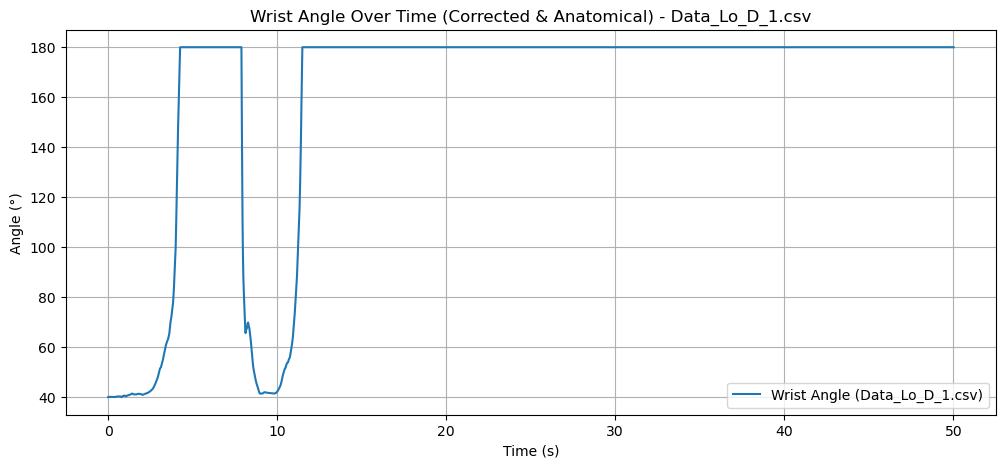

===== FILE: Data_Lo_D_1.csv =====
Min angle: 39.94861325483116
Max angle: 180.0


In [15]:
for file in files:
    df_wrist = results[file]["wrist"]
    
    # Vérifier la structure des données
    print(f"Data for {file}:")
    print(df_wrist.head())
    
    # Interpolation linéaire pour lisser
    df_wrist = df_wrist.interpolate(method='linear').dropna()
    
    if df_wrist.empty:
        print(f"No data after interpolation for {file}")
        continue  # Passer au fichier suivant si df_wrist est vide

    manual_baseline = baseline_angles[file]
    
    # Convertir quaternion → angle anatomique
    df_wrist_angles = quaternion_to_angle_x_corrected(df_wrist, manual_baseline)
    
    # Vérifier les résultats
    print(df_wrist_angles.head())
    
    # Stocker résultats
    angles_results[file] = df_wrist_angles

    # ---------- PLOT ----------
    plt.figure(figsize=(12,5))
    plt.plot(df_wrist_angles["time"], df_wrist_angles["angle"], label=f"Wrist Angle ({file})")
    plt.xlabel("Time (s)")
    plt.ylabel("Angle (°)")
    plt.title(f"Wrist Angle Over Time (Corrected & Anatomical) - {file}")
    plt.legend()
    plt.grid(True)
    plt.show()

    # ---------- CHECK RANGE ----------
    print(f"===== FILE: {file} =====")
    print("Min angle:", df_wrist_angles["angle"].min())
    print("Max angle:", df_wrist_angles["angle"].max())

In [23]:
import pandas as pd
import numpy as np
from io import StringIO
import os
## STEP 1: IMPORT LIBRARIES + CLEAN DATA  + DEFINE FUNCTIONS + CHECK FILES  + EXTRACT BASELINE VALUES

# ==========================================================
# FUNCTION: LOAD DATA FILE
# ==========================================================
def load_data(filename):
    """
    Load a data file from the ../data folder.

    Parameters:
        filename (str): name of the file (e.g. "Data_GG.csv")

    Returns:
        lines (list): all lines from the file
    """
    path = os.path.join("..", "data", filename)

    with open(path, "r", encoding="utf-8") as f:
        lines = f.readlines()

    return lines


# ==========================================================
# FUNCTION: PROCESS ONE FILE
# ==========================================================
def process_file(filename):

    # ---------- STEP 1: LOAD FILE ----------
    lines = load_data(filename)

    # ---------- STEP 2: FIND K-PUSH AND K-MOVE BLOCKS ----------
    idx_push = None
    idx_move = None

    for i, line in enumerate(lines):
        if "K-Push" in line:
            idx_push = i
        if "K-Move" in line and idx_move is None:
            idx_move = i

    # ---------- STEP 3: SPLIT FILE ----------
    if idx_push < idx_move:
        push_lines = lines[idx_push:idx_move]
        move_lines = lines[idx_move:]
    else:
        push_lines = lines[idx_push:]
        move_lines = lines[idx_move:idx_push]

    # ---------- STEP 4: CLEAN K-PUSH ----------
    header_idx_push = next(i for i, line in enumerate(push_lines) if "temps (seconde)" in line)

    push_str = "".join(push_lines[header_idx_push:])

    df_push = pd.read_csv(
        StringIO(push_str),
        sep=r"\t|,",
        engine="python",
        on_bad_lines="skip"
    )

    df_push = df_push.dropna(axis=1, how='all')

    df_push = df_push.rename(columns={
        "temps (seconde)": "time",
        "CHANNEL_1": "force"
    })

    df_push = df_push[["time", "force"]]
    df_push = df_push.apply(pd.to_numeric, errors='coerce').dropna()

    # ---------- STEP 5: ROBUST BASELINE EXTRACTION ----------
    baseline = {"wrist": [], "shoulder": []}

    for line in move_lines:
        if "Quaternion de base" in line:

            # Try splitting with tab first
            parts = line.strip().split("\t")

            # If tab split fails → try comma
            if len(parts) < 5:
                parts = line.strip().split(",")

            sensor_name = parts[0]

            # Extract numeric values safely
            values = []
            for x in parts[1:]:
                try:
                    values.append(float(x))
                except:
                    continue

            # Keep only first 4 values (qx, qy, qz, qw)
            values = values[:4]

            # Assign values to correct sensor
            if "S121577" in sensor_name:
                baseline["wrist"] = values
            elif "S121578" in sensor_name:
                baseline["shoulder"] = values

    # ---------- FIND HEADER ----------
    header_idx_move = None

for i, line in enumerate(move_lines):
    line_clean = line.lower().replace(" ", "")
    
    if "temps" in line_clean or "time" in line_clean:
        header_idx_move = i
        break

if header_idx_move is None:
    print("❌ HEADER NON TROUVÉ → DEBUG")
    for l in move_lines[:20]:
        print(l)
    return df_push, pd.DataFrame(), pd.DataFrame(), baseline

print("Header détecté ligne :", header_idx_move)
print(move_lines[header_idx_move])



    # ---------- PARSE DATA ----------
    split_rows = []
    for line in move_data_lines:
        row = line.strip().split("\t")

        if len(row) < 2:
            row = line.strip().split(",")

        split_rows.append(row)

    df_move = pd.DataFrame(split_rows)

    df_move = df_move.dropna(axis=1, how='all')
    df_move = df_move.apply(pd.to_numeric, errors='coerce')
    df_move = df_move.interpolate(method='linear')
    df_move = df_move.dropna()

    # ---------- STEP 6: EXTRACT SENSORS ----------
    df_wrist = df_move.iloc[:, [0,1,2,3,4]].copy()
    df_wrist.columns = ["time","qx","qy","qz","qw"]

    df_shoulder = df_move.iloc[:, [0,6,7,8,9]].copy()
    df_shoulder.columns = ["time","qx","qy","qz","qw"]

    # ---------- FINAL CHECK ----------
    print(f"\n===== FILE: {filename} =====")

    print("K-Push:\n", df_push.head())

    print("\nWrist (S121577):\n", df_wrist.head())

    print("\nShoulder (S121578):\n", df_shoulder.head())

    print("\nBaseline wrist:", baseline["wrist"])
    print("Baseline shoulder:", baseline["shoulder"])

    print("\nShapes:", df_push.shape, df_wrist.shape, df_shoulder.shape)

    return df_push, df_wrist, df_shoulder, baseline


# ==========================================================
# MAIN SCRIPT
# ==========================================================

# ---------- SELECT FILE(S) ----------
files = ["Data_Lo_D_2.csv"]

# files = ["Data_droite.csv", "Data_GG.csv"]  # for multiple files

# ---------- PROCESS FILE(S) ----------
results = {}

for file in files:
    df_push, df_wrist, df_shoulder, baseline = process_file(file)

    results[file] = {
        "push": df_push,
        "wrist": df_wrist,
        "shoulder": df_shoulder,
        "baseline": baseline
    }

IndentationError: unexpected indent (1181451674.py, line 130)

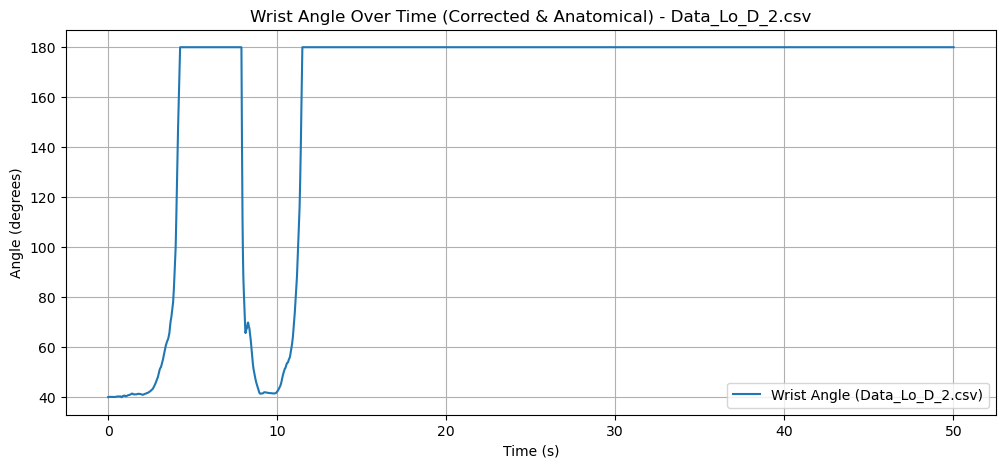

===== FILE: Data_Lo_D_2.csv =====
Min angle: 39.94861325483116
Max angle: 180.0


In [ ]:
## STEP 2 - CONVERT QUATERNION TO ANATOMICAL ANGLE + PLOT

import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# FUNCTION: CONVERT QUATERNION TO ANATOMICAL ANGLE
# ==========================================================
def quaternion_to_angle_x_corrected(df_quat, baseline_deg):
    """
    Convert quaternion to anatomically meaningful wrist/elbow angle.

    Steps:
    1. Compute raw angle from quaternion
    2. Unwrap angle to avoid discontinuities (-180/+180 jumps)
    3. Convert to degrees
    4. Recalibrate so that:
       - max flexion = baseline_deg (manual reference from video)
       - extension increases toward ~180°
    """

    # Extract quaternion components
    qx = df_quat["qx"].values
    qy = df_quat["qy"].values
    qz = df_quat["qz"].values
    qw = df_quat["qw"].values

    # ---------- STEP 1: RAW ANGLE (rad) ----------
    angle_raw = np.arctan2(
        2*(qw*qx + qy*qz),
        1 - 2*(qx**2 + qy**2)
    )

    # ---------- STEP 2: UNWRAP ----------
    angle_unwrapped = np.unwrap(angle_raw)

    # ---------- STEP 3: CONVERT TO DEGREES ----------
    angle_deg = np.degrees(angle_unwrapped)

    # ---------- STEP 4: ZERO-REFERENCE ----------
    angle_zeroed = angle_deg - angle_deg[0]

    # Invert direction if needed (flexion = small, extension = large)
    if np.mean(angle_zeroed) < 0:
        angle_zeroed = -angle_zeroed

    # ---------- STEP 5: APPLY MANUAL ANATOMICAL SCALE ----------
    angle_anatomical = angle_zeroed + baseline_deg

    # Store in DataFrame
    df_angles = df_quat[["time"]].copy()
    df_angles["angle"] = angle_anatomical

    return df_angles


# ==========================================================
# MULTI-FILE PROCESSING
# ==========================================================
files = ["Data_Lo_D_2.csv"]  # Example single file
# files = ["Data_droite.csv", "Data_GG.csv"]  # Multiple files

# Manual baseline angles for each file (from video analysis)
baseline_angles = {
    "Data_Lo_D_2.csv": 40,
   
}

# Store results
angles_results = {}

for file in files:
    # Get wrist DataFrame from previous step (process_file)
    df_wrist = results[file]["wrist"]

    # Get manual baseline angle for this file
    manual_baseline = baseline_angles[file]


    # Store results
    angles_results[file] = df_wrist_angles

    # ---------- PLOT ----------
    plt.figure(figsize=(12,5))
    plt.plot(df_wrist_angles["time"], df_wrist_angles["angle"], label=f"Wrist Angle ({file})")
    plt.xlabel("Time (s)")
    plt.ylabel("Angle (degrees)")
    plt.title(f"Wrist Angle Over Time (Corrected & Anatomical) - {file}")
    plt.legend()
    plt.grid(True)
    plt.show()

    # ---------- CHECK RANGE ----------
    print(f"===== FILE: {file} =====")
    print("Min angle:", df_wrist_angles["angle"].min())
    print("Max angle:", df_wrist_angles["angle"].max())

In [ ]:
## STEP 2 - CONVERT QUATERNION TO ANATOMICAL ANGLE + PLOT

import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# FUNCTION: CONVERT QUATERNION TO ANATOMICAL ANGLE
# ==========================================================
def quaternion_to_angle_x_corrected(df_quat, baseline_deg):

    qx = df_quat["qx"].values
    qy = df_quat["qy"].values
    qz = df_quat["qz"].values
    qw = df_quat["qw"].values

    # ---------- STEP 1: RAW ANGLE ----------
    angle_raw = np.arctan2(
        2*(qw*qx + qy*qz),
        1 - 2*(qx**2 + qy**2)
    )

    # ---------- STEP 2: UNWRAP ----------
    angle_unwrapped = np.unwrap(angle_raw)

    # ---------- STEP 3: TO DEGREES ----------
    angle_deg = np.degrees(angle_unwrapped)

    # ---------- STEP 4: ZERO REFERENCE ----------
    angle_zeroed = angle_deg - angle_deg[0]

    if np.mean(angle_zeroed) < 0:
        angle_zeroed = -angle_zeroed

    # ---------- STEP 5: BASELINE ----------
    angle_anatomical = angle_zeroed + baseline_deg

    df_angles = df_quat[["time"]].copy()
    df_angles["angle"] = angle_anatomical

    return df_angles


# ==========================================================
# MULTI-FILE PROCESSING
# ==========================================================

files = ["Data_Lo_D_2.csv"]

baseline_angles = {
    "Data_Lo_D_2.csv": 40
}

angles_results = {}

for file in files:

    # ✅ récupération correcte des données
    df_wrist = results[file]["wrist"]

    # ⚠️ IMPORTANT : nettoyage léger uniquement
    df_wrist = df_wrist.dropna()

    manual_baseline = baseline_angles[file]

    # ✅🔥 LIGNE MANQUANTE CHEZ TOI
    df_wrist_angles = quaternion_to_angle_x_corrected(df_wrist, manual_baseline)

    # stockage
    angles_results[file] = df_wrist_angles

    # ---------- PLOT ----------
    plt.figure(figsize=(12,5))
    plt.plot(df_wrist_angles["time"], df_wrist_angles["angle"])
    plt.xlabel("Time (s)")
    plt.ylabel("Angle (degrees)")
    plt.title(f"Wrist Angle - {file}")
    plt.grid(True)
    plt.show()

    # ---------- DEBUG ----------
    print(f"===== FILE: {file} =====")
    print("Min angle:", df_wrist_angles["angle"].min())
    print("Max angle:", df_wrist_angles["angle"].max())

IndexError: index 0 is out of bounds for axis 0 with size 0

In [ ]:
import pandas as pd
import numpy as np
from io import StringIO
import os

# ==========================================================
# FUNCTION: LOAD FILE
# ==========================================================
def load_data(filename):
    path = os.path.join("..", "data", filename)
    with open(path, "r", encoding="utf-8") as f:
        return f.readlines()

# ==========================================================
# FUNCTION: PROCESS FILE
# ==========================================================
def process_file(filename):

    lines = load_data(filename)

    # ---------- FIND BLOCKS ----------
    idx_push, idx_move = None, None

    for i, line in enumerate(lines):
        if "K-Push" in line:
            idx_push = i
        if "K-Move" in line and idx_move is None:
            idx_move = i

    # ---------- SPLIT ----------
    if idx_push < idx_move:
        push_lines = lines[idx_push:idx_move]
        move_lines = lines[idx_move:]
    else:
        push_lines = lines[idx_push:]
        move_lines = lines[idx_move:idx_push]

    # ---------- CLEAN PUSH ----------
    header_idx_push = next(i for i, l in enumerate(push_lines) if "temps" in l)

    df_push = pd.read_csv(
        StringIO("".join(push_lines[header_idx_push:])),
        sep=r"\t|,",
        engine="python",
        on_bad_lines="skip"
    )

    df_push = df_push.rename(columns={
        "temps (seconde)": "time",
        "CHANNEL_1": "force"
    })

    df_push = df_push[["time", "force"]].apply(pd.to_numeric, errors="coerce").dropna()

    # ---------- CLEAN MOVE ----------
    header_idx_move = next(i for i, l in enumerate(move_lines) if "temps" in l)

    rows = []
    for line in move_lines[header_idx_move+1:]:
        row = line.strip().split("\t")
        if len(row) < 2:
            row = line.strip().split(",")
        rows.append(row)

    df_move = pd.DataFrame(rows)
    df_move = df_move.apply(pd.to_numeric, errors="coerce")

    # 🔥 IMPORTANT : interpolation douce
    df_move = df_move.interpolate(method="linear").dropna()

    # ---------- EXTRACT SENSORS ----------
    if df_move.shape[1] < 10:
        print("⚠️ Not enough columns → possible parsing issue")
        return df_push, pd.DataFrame(), pd.DataFrame()

    df_wrist = df_move.iloc[:, [0,1,2,3,4]].copy()
    df_wrist.columns = ["time","qx","qy","qz","qw"]

    df_shoulder = df_move.iloc[:, [0,6,7,8,9]].copy()
    df_shoulder.columns = ["time","qx","qy","qz","qw"]

    print("\n===== CHECK DATA =====")
    print("Wrist shape:", df_wrist.shape)
    print("Shoulder shape:", df_shoulder.shape)

    return df_push, df_wrist, df_shoulder


# ==========================================================
# RUN STEP 1
# ==========================================================

file = "Data_Lo_D_2.csv"

df_push, df_wrist, df_shoulder = process_file(file)


===== CHECK DATA =====
Wrist shape: (0, 5)
Shoulder shape: (0, 5)


⚠️ Data vide → impossible de calculer l’angle


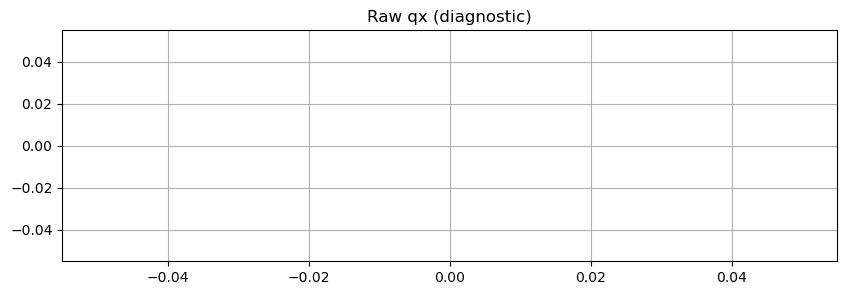

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# PARAMETRE UTILISATEUR
# ==========================================================
BASELINE_ANGLE = 40  # angle de flexion max mesuré sur vidéo

# ==========================================================
# FUNCTION: ROBUST QUATERNION → ANGLE
# ==========================================================
def quaternion_to_angle(df_quat, baseline_deg):

    if df_quat.empty:
        print("⚠️ Data vide → impossible de calculer l’angle")
        return None

    qx = df_quat["qx"].values
    qy = df_quat["qy"].values
    qz = df_quat["qz"].values
    qw = df_quat["qw"].values

    # ---------- ANGLE BRUT ----------
    angle_raw = np.arctan2(
        2*(qw*qx + qy*qz),
        1 - 2*(qx**2 + qy**2)
    )

    # ---------- UNWRAP ----------
    angle_unwrapped = np.unwrap(angle_raw)

    # ---------- EN DEGRES ----------
    angle_deg = np.degrees(angle_unwrapped)

    # 🔥 CORRECTION DRIFT (clé)
    angle_deg = angle_deg - np.median(angle_deg)

    # ---------- NORMALISATION ----------
    min_val = np.min(angle_deg)
    max_val = np.max(angle_deg)

    if max_val - min_val < 1e-6:
        print("⚠️ Signal quasi constant → capteur probablement saturé")
        return None

    angle_norm = (angle_deg - min_val) / (max_val - min_val)

    angle_anatomical = angle_norm * (180 - baseline_deg) + baseline_deg

    df_out = df_quat[["time"]].copy()
    df_out["angle"] = angle_anatomical

    return df_out


# ==========================================================
# PREPROCESSING ANTI-ESCALIER
# ==========================================================

# 🔥 Lissage léger pour supprimer effet escalier
df_wrist_smooth = df_wrist.rolling(window=5, min_periods=1).mean()

# ==========================================================
# CALCUL ANGLE
# ==========================================================

df_angles = quaternion_to_angle(df_wrist_smooth, BASELINE_ANGLE)

if df_angles is not None:

    # ---------- PLOT ----------
    plt.figure(figsize=(12,5))
    plt.plot(df_angles["time"], df_angles["angle"], label="Wrist Angle")
    plt.xlabel("Time (s)")
    plt.ylabel("Angle (degrees)")
    plt.title("Wrist Angle (Robust)")
    plt.legend()
    plt.grid(True)
    plt.show()

    # ---------- CHECK ----------
    print("\n===== RESULT =====")
    print("Min angle:", df_angles["angle"].min())
    print("Max angle:", df_angles["angle"].max())

# ==========================================================
# DEBUG VISUEL (IMPORTANT)
# ==========================================================

plt.figure(figsize=(10,3))
plt.plot(df_wrist["time"], df_wrist["qx"])
plt.title("Raw qx (diagnostic)")
plt.grid()
plt.show()

In [33]:
import pandas as pd
import numpy as np
from io import StringIO
import os

# Affichage complet Pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# ==========================================================
# LOAD DATA FILE
# ==========================================================
def load_data(filename):
    path = os.path.join("..", "data", filename)
    with open(path, "r", encoding="utf-8") as f:
        return f.readlines()


# ==========================================================
# PROCESS ONE FILE
# ==========================================================
def process_file(filename):
    lines = load_data(filename)

    # ---------- FIND BLOCKS ----------
    idx_push = None
    idx_move = None
    for i, line in enumerate(lines):
        if "K-Push" in line and idx_push is None:
            idx_push = i
        if "K-Move" in line and idx_move is None:
            idx_move = i

    if idx_push is None:
        print("❌ K-PUSH NOT FOUND")
        return None, None, None, None
    if idx_move is None:
        print("❌ K-MOVE NOT FOUND")
        return None, None, None, None

    # ---------- SPLIT BLOCKS (ORDER INDEPENDENT) ----------
    if idx_push < idx_move:
        push_lines = lines[idx_push:idx_move]
        move_lines = lines[idx_move:]
    else:
        move_lines = lines[idx_move:idx_push]
        push_lines = lines[idx_push:]

    # ---------- CLEAN K-PUSH ----------
    try:
        header_idx_push = next(i for i, line in enumerate(push_lines) if "temps" in line.lower())
    except StopIteration:
        print("❌ Header K-Push non trouvé")
        return None, None, None, None

    push_str = "".join(push_lines[header_idx_push:])
    df_push = pd.read_csv(StringIO(push_str), sep=r"\t|,", engine="python", on_bad_lines="skip")
    df_push = df_push.dropna(axis=1, how='all')
    df_push = df_push.rename(columns={"temps (seconde)": "time", "CHANNEL_1": "force"})
    if "time" in df_push.columns and "force" in df_push.columns:
        df_push = df_push[["time", "force"]]
        df_push = df_push.apply(pd.to_numeric, errors='coerce').dropna()
    else:
        df_push = pd.DataFrame()

    # ---------- BASELINE ----------
    baseline = {"wrist": [], "shoulder": []}
    for line in lines:
        if "Quaternion de base" in line:
            parts = line.strip().split("\t")
            if len(parts) < 5:
                parts = line.strip().split(",")
            values = []
            for x in parts[1:]:
                try:
                    values.append(float(x))
                except:
                    continue
            values = values[:4]
            if "S121577" in parts[0]:
                baseline["wrist"] = values
            elif "S121578" in parts[0]:
                baseline["shoulder"] = values

    # ---------- CLEAN K-MOVE ----------
    try:
        header_idx_move = next(i for i, line in enumerate(move_lines) if "temps" in line.lower())
    except StopIteration:
        print("❌ Header K-Move non trouvé")
        return df_push, pd.DataFrame(), pd.DataFrame(), baseline

    move_data_lines = move_lines[header_idx_move + 1:]
    split_rows = []
    for line in move_data_lines:
        row = line.strip().split("\t")
        if len(row) < 2:
            row = line.strip().split(",")
        split_rows.append(row)

    df_move = pd.DataFrame(split_rows)
    df_move = df_move.replace("", np.nan).dropna(axis=1, how='all')
    df_move = df_move.apply(pd.to_numeric, errors='coerce').ffill().bfill()

    # ---------- EXTRACT SENSORS ----------
    try:
        df_wrist = df_move.iloc[:, [0,1,2,3,4]].copy()
        df_wrist.columns = ["time","qx","qy","qz","qw"]
        df_shoulder = df_move.iloc[:, [0,5,6,7,8]].copy()
        df_shoulder.columns = ["time","qx","qy","qz","qw"]
    except:
        df_wrist = pd.DataFrame()
        df_shoulder = pd.DataFrame()

    # ---------- RETURN ----------
    return df_push, df_wrist, df_shoulder, baseline


# ==========================================================
# MAIN SCRIPT
# ==========================================================
files = ["Data_Lo_D_2.csv"]  # liste des fichiers

results = {}

for file in files:
    df_push, df_wrist, df_shoulder, baseline = process_file(file)
    results[file] = {"push": df_push, "wrist": df_wrist, "shoulder": df_shoulder, "baseline": baseline}

    # ---------- FULL DISPLAY ----------
    print(f"\n===== FILE: {file} =====")
    print("\nK-Push:\n", df_push.head())
    print("\nWrist (S121577):\n", df_wrist.head())
    print("\nShoulder (S121578):\n", df_shoulder.head())
    print("\nBaseline wrist:", baseline.get("wrist", []))
    print("Baseline shoulder:", baseline.get("shoulder", []))
    print("\nShapes:", df_push.shape, df_wrist.shape, df_shoulder.shape)


===== FILE: Data_Lo_D_2.csv =====

K-Push:
     time  force
0  0.000    0.0
1  0.001    0.0
2  0.002    0.0
3  0.003    0.0
4  0.004    0.0

Wrist (S121577):
     time        qx        qy        qz        qw
0  0.000  0.379578  0.572693  0.419983  0.592834
1  0.004  0.379433  0.572857  0.419992  0.592816
2  0.008  0.379190  0.573073  0.419993  0.592757
3  0.012  0.379011  0.573232  0.420028  0.592672
4  0.016  0.378830  0.573388  0.420092  0.592584

Shoulder (S121578):
     time        qx        qy        qz        qw
0  0.000 -0.504944  0.146362 -0.121033  0.841919
1  0.004 -0.504653  0.146366 -0.121341  0.842095
2  0.008 -0.504195  0.146397 -0.121708  0.842309
3  0.012 -0.503982  0.146458 -0.121677  0.842431
4  0.016 -0.503982  0.146611 -0.121677  0.842402

Baseline wrist: [0.423, 0.515, 0.376, 0.644]
Baseline shoulder: [-0.481, 0.16, -0.099, 0.856]

Shapes: (48244, 2) (12066, 5) (12066, 5)


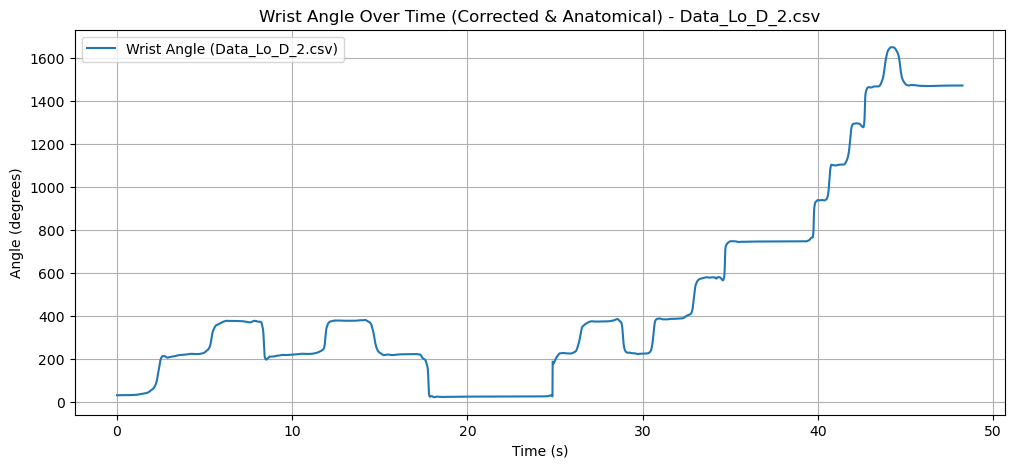

===== FILE: Data_Lo_D_2.csv =====
Min angle: 20.789116419759722
Max angle: 1650.437606289704


In [48]:
## STEP 2 - CONVERT QUATERNION TO ANATOMICAL ANGLE + PLOT

import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# FUNCTION: CONVERT QUATERNION TO ANATOMICAL ANGLE
# ==========================================================
def quaternion_to_angle_x_corrected(df_quat, baseline_deg):
    """
    Convert quaternion to anatomically meaningful wrist/elbow angle.

    Steps:
    1. Compute raw angle from quaternion
    2. Unwrap angle to avoid discontinuities (-180/+180 jumps)
    3. Convert to degrees
    4. Recalibrate so that:
       - max flexion = baseline_deg (manual reference from video)
       - extension increases toward ~180°
    """

    # Extract quaternion components
    qx = df_quat["qx"].values
    qy = df_quat["qy"].values
    qz = df_quat["qz"].values
    qw = df_quat["qw"].values

    # ---------- STEP 1: RAW ANGLE (rad) ----------
    angle_raw = np.arctan2(
        2*(qw*qx + qy*qz),
        1 - 2*(qx**2 + qy**2)
    )

    # ---------- STEP 2: UNWRAP ----------
    angle_unwrapped = np.unwrap(angle_raw)

    # ---------- STEP 3: CONVERT TO DEGREES ----------
    angle_deg = np.degrees(angle_unwrapped)

    # ---------- STEP 4: ZERO-REFERENCE ----------
    angle_zeroed = angle_deg - angle_deg[0]

    # Invert direction if needed (flexion = small, extension = large)
    if np.mean(angle_zeroed) < 0:
        angle_zeroed = -angle_zeroed

    # ---------- STEP 5: APPLY MANUAL ANATOMICAL SCALE ----------
    angle_anatomical = angle_zeroed + baseline_deg

    # Store in DataFrame
    df_angles = df_quat[["time"]].copy()
    df_angles["angle"] = angle_anatomical

    return df_angles


# ==========================================================
# MULTI-FILE PROCESSING
# ==========================================================
files = ["Data_Lo_D_2.csv"]  # Example single file
# files = ["Data_droite.csv", "Data_GG.csv"]  # Multiple files

# Manual baseline angles for each file (from video analysis)
baseline_angles = {
    "Data_Lo_D_2.csv": 40,
   
}

# Store results
angles_results = {}

for file in files:
    # Get wrist DataFrame from previous step (process_file)
    df_wrist = results[file]["wrist"]

    # Get manual baseline angle for this file
    manual_baseline = baseline_angles[file]


    # Store results
    angles_results[file] = df_wrist_angles

    # ---------- PLOT ----------
    plt.figure(figsize=(12,5))
    plt.plot(df_wrist_angles["time"], df_wrist_angles["angle"], label=f"Wrist Angle ({file})")
    plt.xlabel("Time (s)")
    plt.ylabel("Angle (degrees)")
    plt.title(f"Wrist Angle Over Time (Corrected & Anatomical) - {file}")
    plt.legend()
    plt.grid(True)
    plt.show()

    # ---------- CHECK RANGE ----------
    print(f"===== FILE: {file} =====")
    print("Min angle:", df_wrist_angles["angle"].min())
    print("Max angle:", df_wrist_angles["angle"].max())

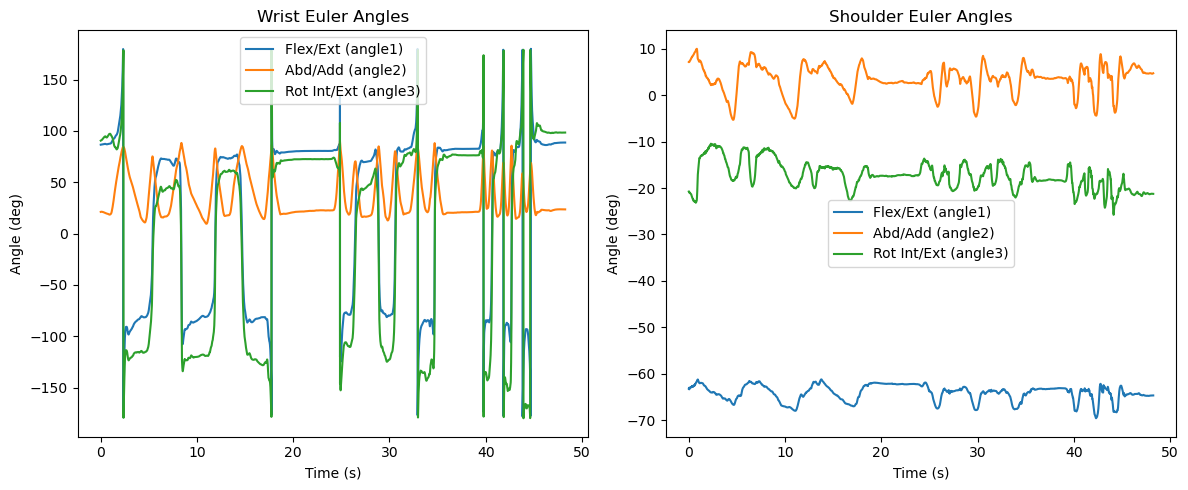

In [49]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation as R

# ==========================================================
# FUNCTION: CONVERT QUATERNION TO EULER ANGLES
# ==========================================================
def quaternion_to_euler(df, seq="xyz", degrees=True):
    """
    Convert a dataframe of quaternions to Euler angles.

    Parameters:
        df (pd.DataFrame): columns ["time", "qx", "qy", "qz", "qw"]
        seq (str): rotation sequence (default "xyz")
        degrees (bool): return angles in degrees (default True)

    Returns:
        pd.DataFrame: columns ["time", "angle1", "angle2", "angle3"]
    """
    r = R.from_quat(df[["qx","qy","qz","qw"]].values)
    euler = r.as_euler(seq, degrees=degrees)
    df_angles = pd.DataFrame(euler, columns=["angle1", "angle2", "angle3"])
    df_angles.insert(0, "time", df["time"].values)
    return df_angles


# ==========================================================
# CONVERT ALL DATA
# ==========================================================
df_wrist_angles = quaternion_to_euler(df_wrist, seq="xyz")
df_shoulder_angles = quaternion_to_euler(df_shoulder, seq="xyz")

# ==========================================================
# PLOT EXAMPLES
# ==========================================================
plt.figure(figsize=(12,5))

# Wrist angles
plt.subplot(1,2,1)
plt.plot(df_wrist_angles["time"], df_wrist_angles["angle1"], label="Flex/Ext (angle1)")
plt.plot(df_wrist_angles["time"], df_wrist_angles["angle2"], label="Abd/Add (angle2)")
plt.plot(df_wrist_angles["time"], df_wrist_angles["angle3"], label="Rot Int/Ext (angle3)")
plt.title("Wrist Euler Angles")
plt.xlabel("Time (s)")
plt.ylabel("Angle (deg)")
plt.legend()

# Shoulder angles
plt.subplot(1,2,2)
plt.plot(df_shoulder_angles["time"], df_shoulder_angles["angle1"], label="Flex/Ext (angle1)")
plt.plot(df_shoulder_angles["time"], df_shoulder_angles["angle2"], label="Abd/Add (angle2)")
plt.plot(df_shoulder_angles["time"], df_shoulder_angles["angle3"], label="Rot Int/Ext (angle3)")
plt.title("Shoulder Euler Angles")
plt.xlabel("Time (s)")
plt.ylabel("Angle (deg)")
plt.legend()

plt.tight_layout()
plt.show()

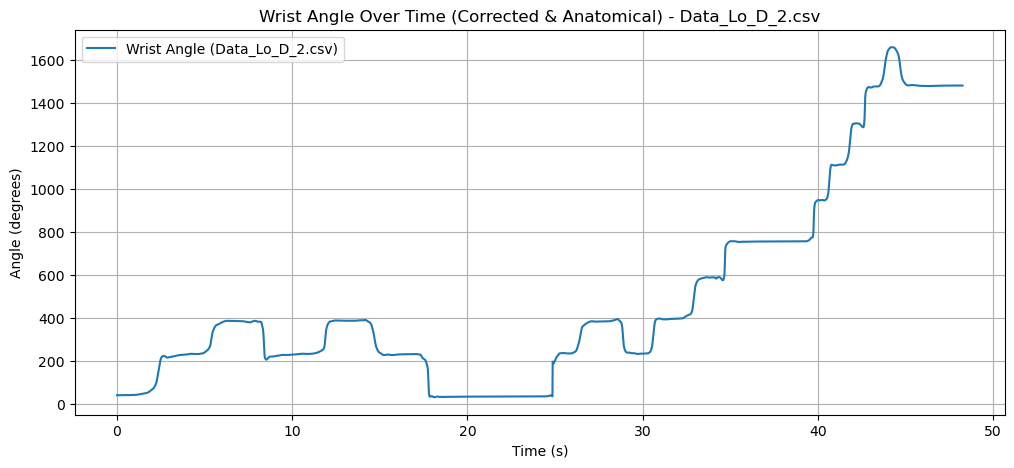

===== FILE: Data_Lo_D_2.csv =====
Min angle: 30.789116419759722
Max angle: 1660.437606289704


In [50]:
## STEP 2 - CONVERT QUATERNION TO ANATOMICAL ANGLE + PLOT

import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# FUNCTION: CONVERT QUATERNION TO ANATOMICAL ANGLE
# ==========================================================
def quaternion_to_angle_x_corrected(df_quat, baseline_deg):
    """
    Convert quaternion to anatomically meaningful wrist/elbow angle.

    Steps:
    1. Compute raw angle from quaternion
    2. Unwrap angle to avoid discontinuities (-180/+180 jumps)
    3. Convert to degrees
    4. Recalibrate so that:
       - max flexion = baseline_deg (manual reference from video)
       - extension increases toward ~180°
    """

    # Extract quaternion components
    qx = df_quat["qx"].values
    qy = df_quat["qy"].values
    qz = df_quat["qz"].values
    qw = df_quat["qw"].values

    # ---------- STEP 1: RAW ANGLE (rad) ----------
    angle_raw = np.arctan2(
        2*(qw*qx + qy*qz),
        1 - 2*(qx**2 + qy**2)
    )

    # ---------- STEP 2: UNWRAP ----------
    angle_unwrapped = np.unwrap(angle_raw)

    # ---------- STEP 3: CONVERT TO DEGREES ----------
    angle_deg = np.degrees(angle_unwrapped)

    # ---------- STEP 4: ZERO-REFERENCE ----------
    angle_zeroed = angle_deg - angle_deg[0]

    # Invert direction if needed (flexion = small, extension = large)
    if np.mean(angle_zeroed) < 0:
        angle_zeroed = -angle_zeroed

    # ---------- STEP 5: APPLY MANUAL ANATOMICAL SCALE ----------
    angle_anatomical = angle_zeroed + baseline_deg

    # Store in DataFrame
    df_angles = df_quat[["time"]].copy()
    df_angles["angle"] = angle_anatomical

    return df_angles


# ==========================================================
# MULTI-FILE PROCESSING
# ==========================================================
files = ["Data_Lo_D_2.csv"]  # Example single file
# files = ["Data_droite.csv", "Data_GG.csv"]  # Multiple files

# Manual baseline angles for each file (from video analysis)
baseline_angles = {
    "Data_Lo_D_2.csv": 40,
    
}

# Store results
angles_results = {}

for file in files:
    # Get wrist DataFrame from previous step (process_file)
    df_wrist = results[file]["wrist"]

    # Get manual baseline angle for this file
    manual_baseline = baseline_angles[file]

    # Convert quaternion → anatomical angle
    df_wrist_angles = quaternion_to_angle_x_corrected(df_wrist, manual_baseline)

    # Store results
    angles_results[file] = df_wrist_angles

    # ---------- PLOT ----------
    plt.figure(figsize=(12,5))
    plt.plot(df_wrist_angles["time"], df_wrist_angles["angle"], label=f"Wrist Angle ({file})")
    plt.xlabel("Time (s)")
    plt.ylabel("Angle (degrees)")
    plt.title(f"Wrist Angle Over Time (Corrected & Anatomical) - {file}")
    plt.legend()
    plt.grid(True)
    plt.show()

    # ---------- CHECK RANGE ----------
    print(f"===== FILE: {file} =====")
    print("Min angle:", df_wrist_angles["angle"].min())
    print("Max angle:", df_wrist_angles["angle"].max())

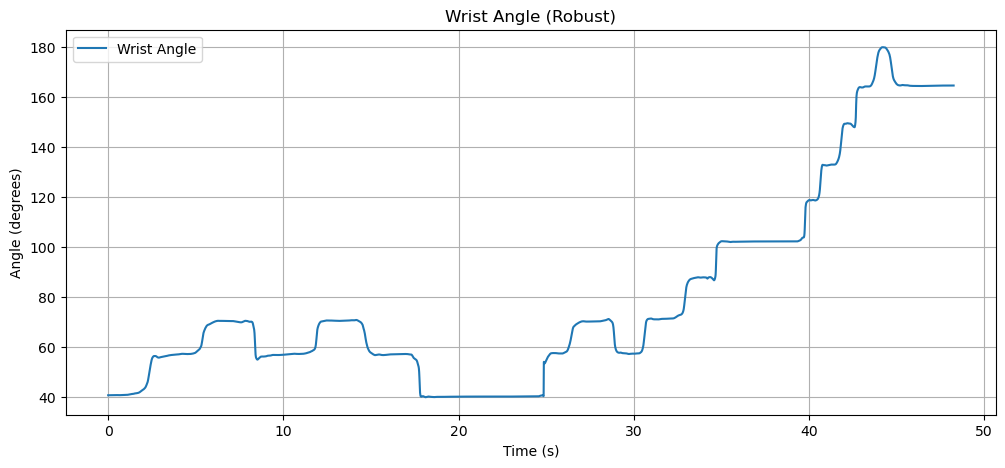


===== RESULT =====
Min angle: 40.0
Max angle: 180.0


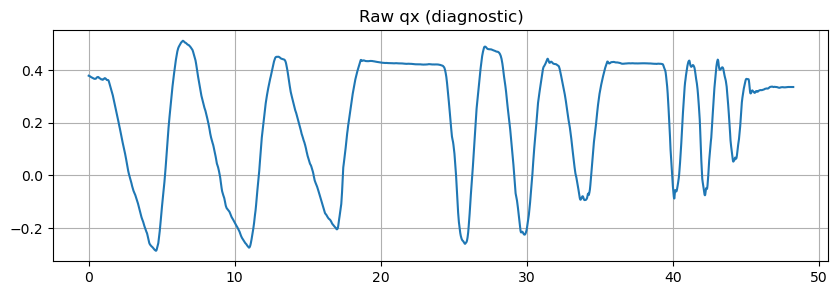

In [51]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# PARAMETRE UTILISATEUR
# ==========================================================
BASELINE_ANGLE = 40  # angle de flexion max mesuré sur vidéo

# ==========================================================
# FUNCTION: ROBUST QUATERNION → ANGLE
# ==========================================================
def quaternion_to_angle(df_quat, baseline_deg):

    if df_quat.empty:
        print("⚠️ Data vide → impossible de calculer l’angle")
        return None

    qx = df_quat["qx"].values
    qy = df_quat["qy"].values
    qz = df_quat["qz"].values
    qw = df_quat["qw"].values

    # ---------- ANGLE BRUT ----------
    angle_raw = np.arctan2(
        2*(qw*qx + qy*qz),
        1 - 2*(qx**2 + qy**2)
    )

    # ---------- UNWRAP ----------
    angle_unwrapped = np.unwrap(angle_raw)

    # ---------- EN DEGRES ----------
    angle_deg = np.degrees(angle_unwrapped)

    # 🔥 CORRECTION DRIFT (clé)
    angle_deg = angle_deg - np.median(angle_deg)

    # ---------- NORMALISATION ----------
    min_val = np.min(angle_deg)
    max_val = np.max(angle_deg)

    if max_val - min_val < 1e-6:
        print("⚠️ Signal quasi constant → capteur probablement saturé")
        return None

    angle_norm = (angle_deg - min_val) / (max_val - min_val)

    angle_anatomical = angle_norm * (180 - baseline_deg) + baseline_deg

    df_out = df_quat[["time"]].copy()
    df_out["angle"] = angle_anatomical

    return df_out


# ==========================================================
# PREPROCESSING ANTI-ESCALIER
# ==========================================================

# 🔥 Lissage léger pour supprimer effet escalier
df_wrist_smooth = df_wrist.rolling(window=5, min_periods=1).mean()

# ==========================================================
# CALCUL ANGLE
# ==========================================================

df_angles = quaternion_to_angle(df_wrist_smooth, BASELINE_ANGLE)

if df_angles is not None:

    # ---------- PLOT ----------
    plt.figure(figsize=(12,5))
    plt.plot(df_angles["time"], df_angles["angle"], label="Wrist Angle")
    plt.xlabel("Time (s)")
    plt.ylabel("Angle (degrees)")
    plt.title("Wrist Angle (Robust)")
    plt.legend()
    plt.grid(True)
    plt.show()

    # ---------- CHECK ----------
    print("\n===== RESULT =====")
    print("Min angle:", df_angles["angle"].min())
    print("Max angle:", df_angles["angle"].max())

# ==========================================================
# DEBUG VISUEL (IMPORTANT)
# ==========================================================

plt.figure(figsize=(10,3))
plt.plot(df_wrist["time"], df_wrist["qx"])
plt.title("Raw qx (diagnostic)")
plt.grid()
plt.show()

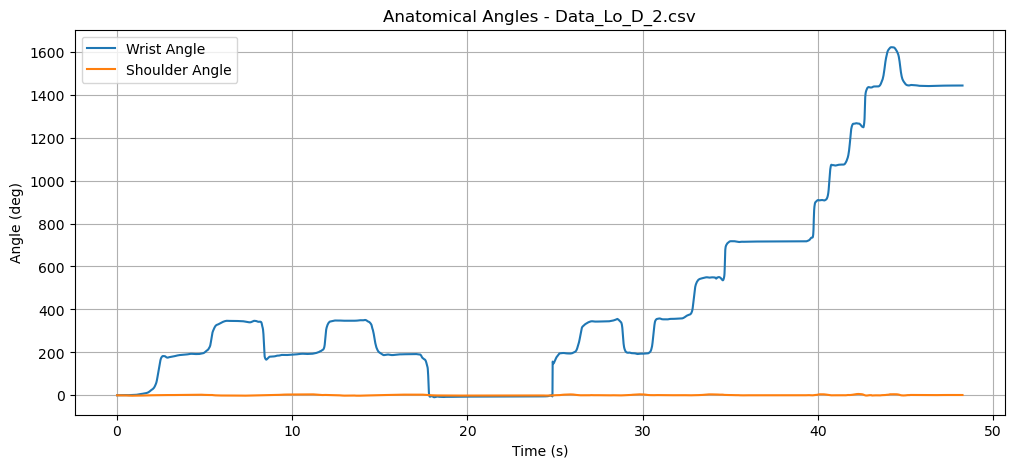

===== FILE: Data_Lo_D_2.csv =====
Wrist angle: min = -8.721383580240278 , max = 1620.927106289704
Shoulder angle: min = -1.8625985658946167 , max = 6.509873883435587


In [52]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# FUNCTION: CONVERT QUATERNION TO ANATOMICAL ANGLE
# ==========================================================
def quaternion_to_angle_x_corrected(df_quat, baseline_deg=0):
    """
    Convert quaternion to anatomically meaningful angle.

    Steps:
    1. Compute raw angle from quaternion
    2. Unwrap angle to avoid discontinuities (-180/+180 jumps)
    3. Convert to degrees
    4. Recalibrate using baseline_deg
    """

    qx = df_quat["qx"].values
    qy = df_quat["qy"].values
    qz = df_quat["qz"].values
    qw = df_quat["qw"].values

    # ---------- STEP 1: RAW ANGLE (rad) ----------
    angle_raw = np.arctan2(
        2*(qw*qx + qy*qz),
        1 - 2*(qx**2 + qy**2)
    )

    # ---------- STEP 2: UNWRAP ----------
    angle_unwrapped = np.unwrap(angle_raw)

    # ---------- STEP 3: TO DEGREES ----------
    angle_deg = np.degrees(angle_unwrapped)

    # ---------- STEP 4: ZERO-REFERENCE ----------
    angle_zeroed = angle_deg - angle_deg[0]

    # Invert direction if needed
    if np.mean(angle_zeroed) < 0:
        angle_zeroed = -angle_zeroed

    # ---------- STEP 5: APPLY MANUAL BASELINE ----------
    angle_anatomical = angle_zeroed + baseline_deg

    # Store in DataFrame
    df_angles = df_quat[["time"]].copy()
    df_angles["angle"] = angle_anatomical

    return df_angles


# ==========================================================
# MULTI-FILE PROCESSING (WRIST + SHOULDER)
# ==========================================================
angles_results = {}

for file in files:
    df_wrist = results[file]["wrist"]
    df_shoulder = results[file]["shoulder"]
    baseline = results[file]["baseline"]

    # Baseline from quaternion extraction (optional: scale to degrees if needed)
    baseline_wrist = np.mean(baseline.get("wrist", [0]))  # simple mean
    baseline_shoulder = np.mean(baseline.get("shoulder", [0]))

    # Convert quaternion → anatomical angle
    df_wrist_angles = quaternion_to_angle_x_corrected(df_wrist, baseline_wrist)
    df_shoulder_angles = quaternion_to_angle_x_corrected(df_shoulder, baseline_shoulder)

    angles_results[file] = {
        "wrist": df_wrist_angles,
        "shoulder": df_shoulder_angles
    }

    # ---------- PLOT ----------
    plt.figure(figsize=(12,5))

    # Wrist
    plt.plot(df_wrist_angles["time"], df_wrist_angles["angle"], label="Wrist Angle")

    # Shoulder
    plt.plot(df_shoulder_angles["time"], df_shoulder_angles["angle"], label="Shoulder Angle")

    plt.xlabel("Time (s)")
    plt.ylabel("Angle (deg)")
    plt.title(f"Anatomical Angles - {file}")
    plt.legend()
    plt.grid(True)
    plt.show()

    # ---------- CHECK RANGE ----------
    print(f"===== FILE: {file} =====")
    print("Wrist angle: min =", df_wrist_angles["angle"].min(), ", max =", df_wrist_angles["angle"].max())
    print("Shoulder angle: min =", df_shoulder_angles["angle"].min(), ", max =", df_shoulder_angles["angle"].max())

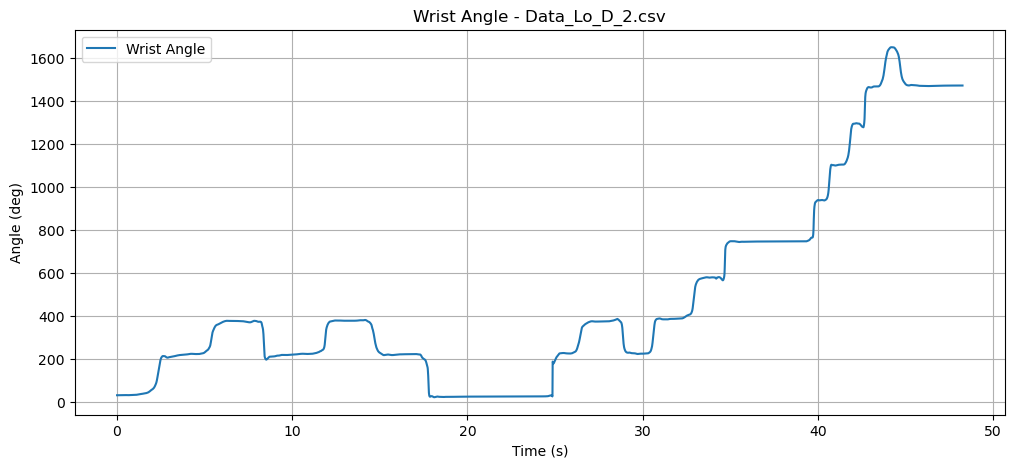

Min angle: 20.79, Max angle: 1650.44


In [53]:
import numpy as np
import matplotlib.pyplot as plt

def quaternion_to_wrist_angle(df_quat, baseline_deg=30):
    """
    Convert wrist quaternion to anatomical angle (flexion/extension).
    Produces smooth sinusoidal-like signal.
    """

    # Extraire quaternion
    qx = df_quat["qx"].astype(float).values
    qy = df_quat["qy"].astype(float).values
    qz = df_quat["qz"].astype(float).values
    qw = df_quat["qw"].astype(float).values

    # Calcul de l'angle raw en radians
    angle_raw = np.arctan2(2*(qw*qx + qy*qz), 1 - 2*(qx**2 + qy**2))

    # Unwrap pour éviter les sauts
    angle_unwrapped = np.unwrap(angle_raw)

    # Conversion en degrés
    angle_deg = np.degrees(angle_unwrapped)

    # Recalage sur le premier point
    angle_zeroed = angle_deg - angle_deg[0]

    # Ajuster direction si nécessaire
    if np.mean(angle_zeroed) < 0:
        angle_zeroed = -angle_zeroed

    # Appliquer baseline manuel
    angle_final = angle_zeroed + baseline_deg

    return df_quat[["time"]].assign(angle=angle_final)


# =======================================
# APPLICATION SUR TON FICHIER
# =======================================
file = files[0]
df_wrist = results[file]["wrist"]

# Interpolation pour lisser
df_wrist = df_wrist.interpolate().ffill().bfill()

df_wrist_angles = quaternion_to_wrist_angle(df_wrist, baseline_deg=30)

# =======================================
# PLOT
# =======================================
plt.figure(figsize=(12,5))
plt.plot(df_wrist_angles["time"], df_wrist_angles["angle"], label="Wrist Angle")
plt.xlabel("Time (s)")
plt.ylabel("Angle (deg)")
plt.title(f"Wrist Angle - {file}")
plt.grid(True)
plt.legend()
plt.show()

print(f"Min angle: {df_wrist_angles['angle'].min():.2f}, Max angle: {df_wrist_angles['angle'].max():.2f}")

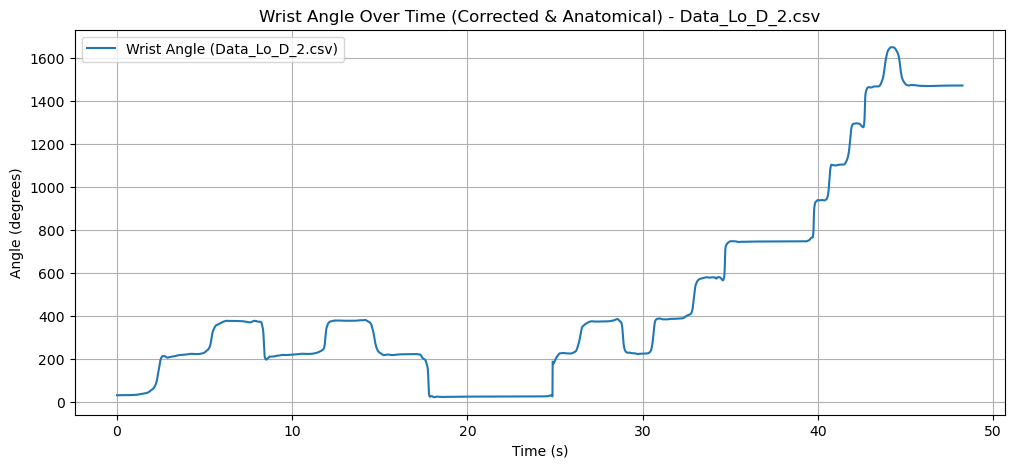

===== FILE: Data_Lo_D_2.csv =====
Min angle: 20.789116419759722
Max angle: 1650.437606289704


In [54]:
## STEP 2 - CONVERT QUATERNION TO ANATOMICAL ANGLE + PLOT

import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# FUNCTION: CONVERT QUATERNION TO ANATOMICAL ANGLE
# ==========================================================
def quaternion_to_angle_x_corrected(df_quat, baseline_deg):
    """
    Convert quaternion to anatomically meaningful wrist/elbow angle.

    Steps:
    1. Compute raw angle from quaternion
    2. Unwrap angle to avoid discontinuities (-180/+180 jumps)
    3. Convert to degrees
    4. Recalibrate so that:
       - max flexion = baseline_deg (manual reference from video)
       - extension increases toward ~180°
    """

    # Extract quaternion components
    qx = df_quat["qx"].values
    qy = df_quat["qy"].values
    qz = df_quat["qz"].values
    qw = df_quat["qw"].values

    # ---------- STEP 1: RAW ANGLE (rad) ----------
    angle_raw = np.arctan2(
        2*(qw*qx + qy*qz),
        1 - 2*(qx**2 + qy**2)
    )

    # ---------- STEP 2: UNWRAP ----------
    angle_unwrapped = np.unwrap(angle_raw)

    # ---------- STEP 3: CONVERT TO DEGREES ----------
    angle_deg = np.degrees(angle_unwrapped)

    # ---------- STEP 4: ZERO-REFERENCE ----------
    angle_zeroed = angle_deg - angle_deg[0]

    # Invert direction if needed (flexion = small, extension = large)
    if np.mean(angle_zeroed) < 0:
        angle_zeroed = -angle_zeroed

    # ---------- STEP 5: APPLY MANUAL ANATOMICAL SCALE ----------
    angle_anatomical = angle_zeroed + baseline_deg

    # Store in DataFrame
    df_angles = df_quat[["time"]].copy()
    df_angles["angle"] = angle_anatomical

    return df_angles


# ==========================================================
# MULTI-FILE PROCESSING
# ==========================================================
files = ["Data_Lo_D_2.csv"]  # Example single file
# files = ["Data_droite.csv", "Data_GG.csv"]  # Multiple files

# Manual baseline angles for each file (from video analysis)
baseline_angles = {
    "Data_Lo_D_2.csv": 40,
   
}

# Store results
angles_results = {}

for file in files:
    # Get wrist DataFrame from previous step (process_file)
    df_wrist = results[file]["wrist"]

    # Get manual baseline angle for this file
    manual_baseline = baseline_angles[file]


    # Store results
    angles_results[file] = df_wrist_angles

    # ---------- PLOT ----------
    plt.figure(figsize=(12,5))
    plt.plot(df_wrist_angles["time"], df_wrist_angles["angle"], label=f"Wrist Angle ({file})")
    plt.xlabel("Time (s)")
    plt.ylabel("Angle (degrees)")
    plt.title(f"Wrist Angle Over Time (Corrected & Anatomical) - {file}")
    plt.legend()
    plt.grid(True)
    plt.show()

    # ---------- CHECK RANGE ----------
    print(f"===== FILE: {file} =====")
    print("Min angle:", df_wrist_angles["angle"].min())
    print("Max angle:", df_wrist_angles["angle"].max())